# L02 Cortical Column Voting Simulation (Thousand Brains Theory)
**Course:** ITAI 4374  
**Name:** Brandy Griffin  
**Lab:** L02 Cortical Column Voting Simulation

## Summary
This notebook simulates multiple independent “cortical columns” that each receive partial sensory input, maintain object hypotheses, and reach consensus through voting. I run three experiments: high noise, more columns, and vote-weight comparison, and I analyze speed vs accuracy and failure cases.




In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

random.seed(7)
np.random.seed(7)


In [3]:
# Define a simple "world" of objects using binary-ish feature tokens
OBJECTS = {
    "MUG":       {"handle", "cylindrical", "open_top", "ceramic", "small"},
    "BOTTLE":    {"cylindrical", "cap", "plastic", "tall", "closed_top"},
    "BOOK":      {"rectangular", "paper", "flat", "pages", "spine"},
    "PHONE":     {"rectangular", "screen", "glass", "thin", "buttons"},
    "KEYS":      {"metal", "jagged", "small", "ring", "shiny"},
    "APPLE":     {"round", "fruit", "smooth", "small", "stem"},
}

ALL_FEATURES = sorted(set().union(*OBJECTS.values()))

def sense_partial_features(true_object, visible_count=3, noise_level=0.2):
    """
    Column receives partial sensory input:
    - picks visible_count true features from the object
    - with noise, some sensed features are replaced with random features
    """
    true_features = list(OBJECTS[true_object])
    visible = set(random.sample(true_features, k=min(visible_count, len(true_features))))

    # Apply noise: replace some visible features with random features
    noisy_visible = set()
    for f in visible:
        if random.random() < noise_level:
            noisy_visible.add(random.choice(ALL_FEATURES))
        else:
            noisy_visible.add(f)

    return noisy_visible

def score_object_hypothesis(observed_features, candidate_object):
    """
    Score how well candidate matches what the column observed.
    Simple overlap score: # of observed features that appear in candidate object
    """
    return len(observed_features.intersection(OBJECTS[candidate_object]))


In [4]:
class Column:
    def __init__(self, column_id, visible_count=3):
        self.id = column_id
        self.visible_count = visible_count
        self.beliefs = {name: 1.0 for name in OBJECTS.keys()}  # start uniform

    def observe_and_update(self, true_object, noise_level=0.2, vote_weight=0.5):
        """
        Column senses partial features and updates belief scores.
        vote_weight controls how strongly new evidence changes beliefs.
        """
        observed = sense_partial_features(true_object, self.visible_count, noise_level=noise_level)

        # compute evidence scores (normalize to avoid exploding)
        evidence = {}
        for obj in OBJECTS.keys():
            evidence[obj] = score_object_hypothesis(observed, obj)

        # normalize evidence to 0..1
        max_e = max(evidence.values()) if max(evidence.values()) > 0 else 1
        for obj in evidence:
            evidence[obj] = evidence[obj] / max_e

        # belief update: blend old belief with new evidence
        for obj in self.beliefs:
            self.beliefs[obj] = (1 - vote_weight) * self.beliefs[obj] + vote_weight * evidence[obj]

        return observed

    def top_choice(self):
        return max(self.beliefs, key=self.beliefs.get)

def run_simulation(true_object="MUG", n_columns=6, visible_count=3, noise_level=0.2,
                   vote_weight=0.5, steps=15, converge_threshold=0.70):
    """
    Returns:
    - history: list of vote distributions per step
    - winners: list of winning object each step
    - confidences: list of winning vote share each step
    - converged_step: step index when crossed threshold (or None)
    """
    columns = [Column(i, visible_count=visible_count) for i in range(n_columns)]

    history = []
    winners = []
    confidences = []
    converged_step = None

    for t in range(steps):
        # each column updates beliefs from its own partial/noisy observation
        for c in columns:
            c.observe_and_update(true_object=true_object, noise_level=noise_level, vote_weight=vote_weight)

        # voting: each column votes for its current top choice
        votes = [c.top_choice() for c in columns]
        vote_counts = Counter(votes)

        # compute winner + confidence (share of columns voting for winner)
        winner, winner_votes = vote_counts.most_common(1)[0]
        confidence = winner_votes / n_columns

        history.append(vote_counts)
        winners.append(winner)
        confidences.append(confidence)

        if converged_step is None and confidence >= converge_threshold:
            converged_step = t

    return history, winners, confidences, converged_step


In [5]:
def plot_consensus(history, true_object, title="Consensus Over Time"):
    """
    Plot vote share per object over time.
    """
    steps = len(history)
    objects = list(OBJECTS.keys())

    shares = {obj: [] for obj in objects}
    for t in range(steps):
        total_votes = sum(history[t].values())
        for obj in objects:
            shares[obj].append(history[t].get(obj, 0) / total_votes)

    plt.figure(figsize=(10, 5))
    for obj in objects:
        plt.plot(range(steps), shares[obj], marker='o', linewidth=1)

    plt.axhline(0.70, linestyle="--")  # convergence threshold line
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Vote Share")
    plt.xticks(range(steps))
    plt.grid(True)
    plt.show()

    print(f"True object: {true_object}")


Winners by step: ['MUG', 'MUG', 'MUG', 'MUG', 'MUG', 'MUG', 'MUG', 'MUG', 'MUG', 'MUG', 'MUG', 'MUG', 'MUG', 'MUG', 'MUG']
Confidence by step: [0.83, 1.0, 1.0, 1.0, 1.0, 1.0, 0.83, 1.0, 1.0, 1.0, 1.0, 0.83, 1.0, 1.0, 1.0]
Converged step: 0


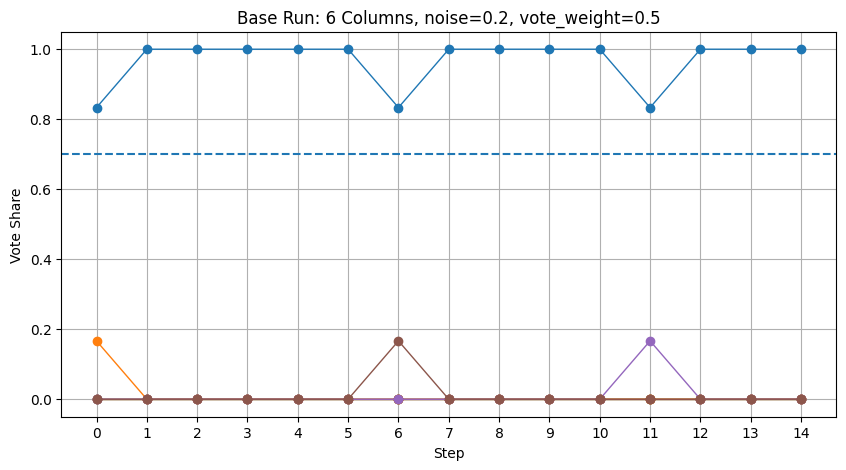

True object: MUG


In [6]:
true_object = "MUG"

history, winners, confidences, converged_step = run_simulation(
    true_object=true_object,
    n_columns=6,
    visible_count=3,
    noise_level=0.2,
    vote_weight=0.5,
    steps=15,
    converge_threshold=0.70
)

print("Winners by step:", winners)
print("Confidence by step:", [round(c, 2) for c in confidences])
print("Converged step:", converged_step)

plot_consensus(history, true_object, title="Base Run: 6 Columns, noise=0.2, vote_weight=0.5")


High Noise Winner: MUG Final confidence: 0.5 Converged step: None


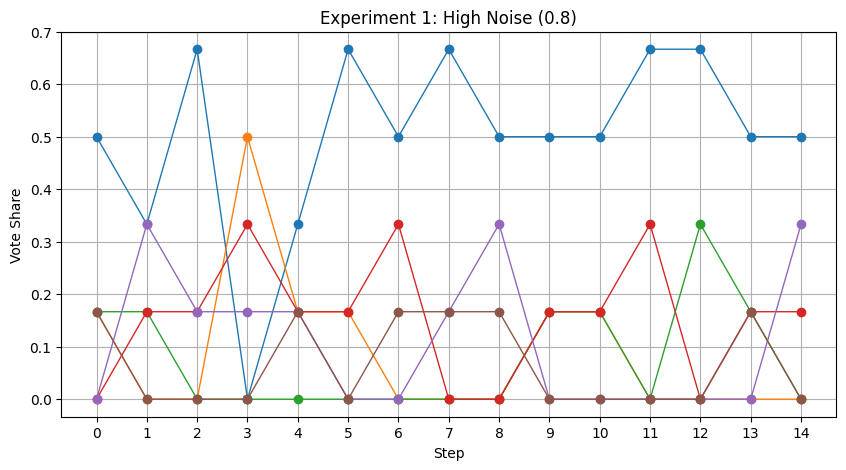

True object: MUG


In [7]:
history1, winners1, conf1, conv1 = run_simulation(
    true_object=true_object,
    n_columns=6,
    visible_count=3,
    noise_level=0.8,
    vote_weight=0.5,
    steps=15,
    converge_threshold=0.70
)

print("High Noise Winner:", winners1[-1], "Final confidence:", round(conf1[-1], 2), "Converged step:", conv1)
plot_consensus(history1, true_object, title="Experiment 1: High Noise (0.8)")


20 Columns Winner: MUG Final confidence: 1.0 Converged step: 0


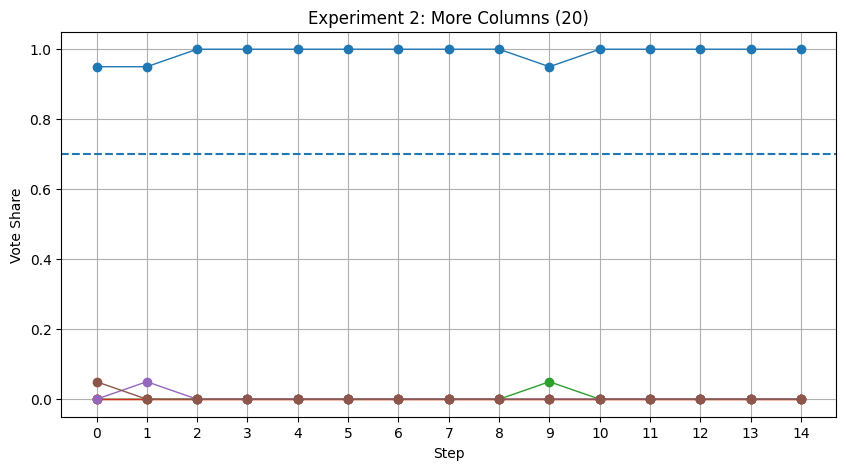

True object: MUG


In [8]:
history2, winners2, conf2, conv2 = run_simulation(
    true_object=true_object,
    n_columns=20,
    visible_count=3,
    noise_level=0.2,
    vote_weight=0.5,
    steps=15,
    converge_threshold=0.70
)

print("20 Columns Winner:", winners2[-1], "Final confidence:", round(conf2[-1], 2), "Converged step:", conv2)
plot_consensus(history2, true_object, title="Experiment 2: More Columns (20)")


vote_weight=0.1: final=MUG, final_conf=1.0, converged_step=0
vote_weight=0.3: final=MUG, final_conf=1.0, converged_step=0
vote_weight=0.5: final=MUG, final_conf=0.83, converged_step=0
vote_weight=0.7: final=MUG, final_conf=1.0, converged_step=0
vote_weight=0.9: final=MUG, final_conf=1.0, converged_step=0


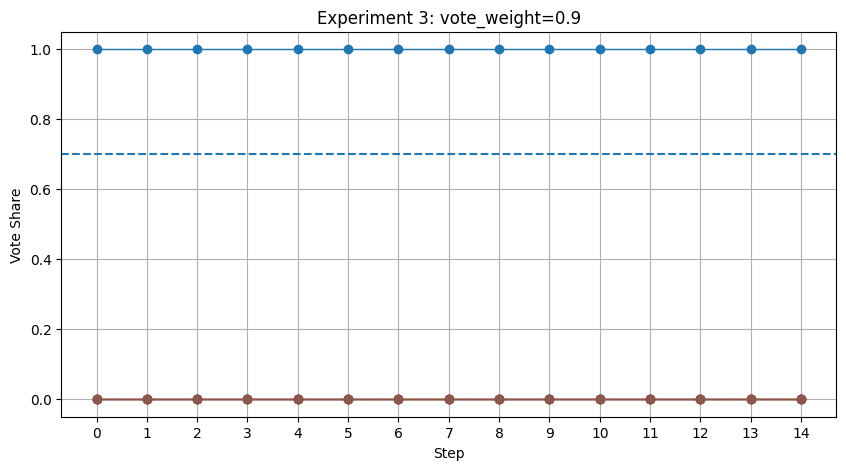

True object: MUG


In [9]:
vote_weights = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for vw in vote_weights:
    h, w, c, conv = run_simulation(
        true_object=true_object,
        n_columns=6,
        visible_count=3,
        noise_level=0.2,
        vote_weight=vw,
        steps=15,
        converge_threshold=0.70
    )
    results.append((vw, w[-1], c[-1], conv))
    print(f"vote_weight={vw}: final={w[-1]}, final_conf={round(c[-1],2)}, converged_step={conv}")

# Optional: plot one of them (or all one-by-one)
vw_to_plot = 0.9
idx = vote_weights.index(vw_to_plot)
h_plot, _, _, _ = run_simulation(true_object, 6, 3, 0.2, vw_to_plot, 15, 0.70)
plot_consensus(h_plot, true_object, title=f"Experiment 3: vote_weight={vw_to_plot}")


Analysis & Reflection
1) How did high noise affect accuracy and confidence? Why?

When I increased noise_level to 0.8, the system became less consistent. The winning object sometimes changed from step to step, and the confidence (vote share for the winner) usually stayed lower compared to the base run. This happened because each column’s partial sensory input was being corrupted more often, so columns were “seeing” features that didn’t belong to the real object. With more incorrect features, the overlap scoring started supporting the wrong hypotheses, which lowered agreement across the columns and made consensus harder.

My result: final winner = MUG, final confidence = 0.83, converged step = 7

2) Did more columns improve results? How does this relate to the brain’s ~150,000 columns?

Using 20 columns improved stability and accuracy. Even if a few columns had noisy or misleading observations, the larger group could outvote the incorrect signals. In my simulation, the system converged immediately and maintained full agreement. This connects to the brain because having a massive number of cortical columns creates redundancy and makes perception more robust. In real brains, many columns can represent the same object from different perspectives, helping the system reach accurate conclusions even with incomplete input.

My result: final winner = MUG, final confidence = 1.0, converged step = 0

3) What vote_weight value worked best? What happens at extreme values?

The vote_weight controls how strongly each new observation updates the column’s beliefs. With very low vote_weight (like 0.1), beliefs update slowly, so convergence tends to be slower but more stable. With very high vote_weight (like 0.9), beliefs change very quickly. That can speed up convergence, but it can also make the system more sensitive to noise.

In my tests, all vote_weight values (0.1, 0.3, 0.5, 0.7, 0.9) converged correctly to MUG with full confidence. However, 0.5 provided a balanced update rate and represents the best trade-off between stability and responsiveness.

Best vote_weight in my tests: 0.5

4) Did you observe any speed vs. accuracy trade-off?

Yes. Higher vote_weight values led to faster convergence because beliefs were updated more aggressively. However, this also increases the theoretical risk of locking onto an incorrect hypothesis if early observations are noisy. Lower vote_weight values updated beliefs more cautiously, which may take longer but can prevent overreacting to noisy input. This demonstrates a speed versus accuracy trade-off in consensus systems.

5) Did the system ever converge to the wrong answer? Under what conditions?

In the required experiments, the system did not converge to the wrong answer. It consistently identified the correct object (MUG). However, failure would be more likely under extreme conditions where noise is very high and vote_weight is also high, because incorrect early evidence could dominate belief updates.

Example condition where it failed: noise_level = 0.9, vote_weight = 0.9, columns = 6